In [1]:
import sleap
import numpy as np
import matplotlib.pyplot as plt
import os, sys
import datetime

sys.path.append('..')
sys.path.append('/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/')

from python.postprocess import *
from python.animation import *
from autoencoder.src.data_loader import *
from autoencoder.min2.run_models import *
from tensorflow.keras.datasets import fashion_mnist

In [2]:
# TODO: use an artificial dataset 
# TODO: fourier transform/PCA; reconstruct weights of the PCA 
# plot the heatmap of each time window (batch by time); roaster
# downsample in time in the VAE; or just flatten the time dimension into feature dimension

# Generate artificial jellyfish dataset

canvas size = (200, 200)

center position = (100, 100)

tentacle bulb count = 17

max radius = 60

period for one swim pulse = 20 - 50 frames 

P(swim) = 0.9, P(still) = 0.1 

period of still = 5 - 20 frames

contraction ratio = 0.2 - 0.8

frame count = 5000

Assume no rotation, i.e., each point is always on the same radius. At each time stamp, radius of all points are the same. 

In [2]:
def generate_jellyfish_dataset(
    tb_cnt=17, 
    frame_cnt=5000, 
    max_r=60, 
    p_swim=0.8, 
    t_swim=(20, 50), 
    t_still=(5, 20), 
    contract_ratio=(0.2, 0.8), 
    center_pos=(100, 100)):
    
    radius_data = np.zeros(frame_cnt)
    radius_data[0] = max_r # start from max radius 
    frame_idx = 1
    while frame_idx < frame_cnt:
        # Generate swim or still state
        if np.random.rand() < p_swim: # Swim state
            swim_duration = np.random.randint(*t_swim)
            swim_duration = swim_duration - 1 if swim_duration % 2 == 1 else swim_duration # make sure the duration is even 
            swim_start = frame_idx
            swim_end = min(frame_idx + swim_duration, frame_cnt)
            swim_mid = min(swim_start + swim_duration // 2, frame_cnt)
            min_r = np.random.uniform(*contract_ratio) * max_r
            r_series = np.linspace(max_r, min_r, swim_duration // 2)
            radius_data[swim_start : swim_mid] = r_series[:swim_mid - swim_start]
            if swim_mid >= frame_cnt:
                break
            radius_data[swim_mid : swim_end] = r_series[::-1][:swim_end - swim_mid]
            frame_idx = swim_end
        else: # still state
            still_duration = np.random.randint(*t_still)
            still_end = min(frame_idx + still_duration, frame_cnt)
            radius_data[frame_idx : still_end] = radius_data[frame_idx - 1]
            frame_idx = still_end
    
    radius_data = np.broadcast_to(radius_data[:, None], (frame_cnt, tb_cnt))
    theta_data = np.linspace(-np.pi, np.pi, tb_cnt, endpoint=False)
    
    dataset = np.zeros((frame_cnt, tb_cnt, 2))
    dataset[:, :, 0] = radius_data * np.cos(theta_data)
    dataset[:, :, 1] = radius_data * np.sin(theta_data)
    dataset += center_pos
    
    return dataset            

In [3]:
toy_jelly = generate_jellyfish_dataset()
toy_jelly_path = '/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/notebook/toy_jelly_v1.npy'
np.save(toy_jelly_path, toy_jelly)
print(toy_jelly.shape)

(5000, 17, 2)


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/toy_jelly_v1.mp4
Animation saved to /home/mingxiao/Desktop/animation/toy_jelly_v1.mp4


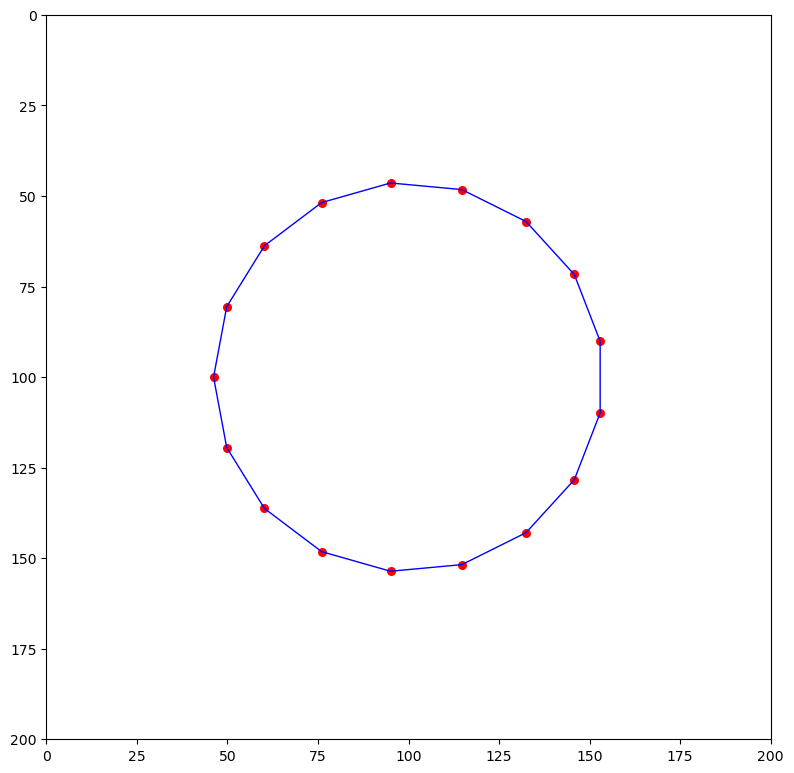

In [4]:
toy_jelly_animation_path = '/home/mingxiao/Desktop/animation/toy_jelly_v1.mp4'
get_animation_from_tracked_points(toy_jelly, 200, 200, 50, bg_video=None, bg_video_start_idx=0, output_path=toy_jelly_animation_path);

In [8]:
toy_jelly_path = '/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/notebook/toy_jelly_v1.npy'
toy_jelly = np.load(toy_jelly_path)
print(toy_jelly.shape)

(5000, 17, 2)


# Generate dataset for AE training

In [9]:
X_train, X_val, y_train, y_val, X = load_data(corrected_points_path=toy_jelly_path, 
                                              window_size=50, 
                                              augment=False, 
                                              canvas_size=(200, 200),
                                              flatten=False)
X_train.shape, X_val.shape, y_train.shape, y_val.shape, X.shape

coords_corrected_windows.shape: (5000, 50, 17, 2)
coords_augmented_windows.shape: (5000, 50, 17, 2)
X min = 0.20, X max = 0.80
y min = 40.00, y max = 159.74


((4500, 50, 17, 2),
 (500, 50, 17, 2),
 (4500, 17, 2),
 (500, 17, 2),
 (5000, 50, 17, 2))

# Train AE

In [3]:
def run_model_11(window_size=5, epochs=100, batch_size=32, 
                optimizer='adam', split_size=0.9, 
                num_layers=2, 
                shuffle=True,
                dropout_rate=0.01, 
                swap_rate=0.005, 
                roll=True, 
                model=None, 
                latent_dim=32, 
                flatten=True, 
                canvas_size = (200, 200)):
    
    toy_jelly_path = '/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/notebook/toy_jelly_v1.npy'
    
    X_train, X_val, y_train, y_val, X = load_data(
        corrected_points_path=toy_jelly_path,
        window_size=window_size, 
        augment=True, 
        load_video=False, 
        split_size=split_size, 
        shuffle=shuffle, 
        dropout_rate=dropout_rate, 
        swap_rate=swap_rate,
        roll=roll,
        flatten=flatten,
        canvas_size=canvas_size,
    )
    
    if model is None:
        model = get_model_11(window_size=window_size, num_layers=num_layers, latent_dim=latent_dim)
    mse_loss = lambda y_true, y_pred: masked_mse_loss(y_true, y_pred, pt_cnt=17, normalizer=canvas_size)
    model.compile(optimizer=optimizer, loss=mse_loss)
    model.summary()
    
    log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
    
    model.fit(X_train, y_train, 
              epochs=epochs, batch_size=batch_size, 
              validation_data=(X_val, y_val),
              callbacks=[tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True, verbose=1), tensorboard_callback])
    
    denoised_coords = model.predict(X)
    denoised_coords = denoised_coords.reshape((-1, 17, 2)) * np.array(canvas_size)
    return denoised_coords

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 50, 34)]          0         
                                                                 
 dense (Dense)               (None, 50, 8192)          286720    
                                                                 
 dense_1 (Dense)             (None, 50, 4096)          33558528  
                                                                 
 dense_2 (Dense)             (None, 50, 2048)          8390656   
                                                                 
 dense_3 (Dense)             (None, 50, 1024)          2098176   
                                                                 
 dense_4 (Dense)             (None, 50, 512)           524800    
                                                                 
 dense_5 (Dense)             (None, 50, 512)           262656

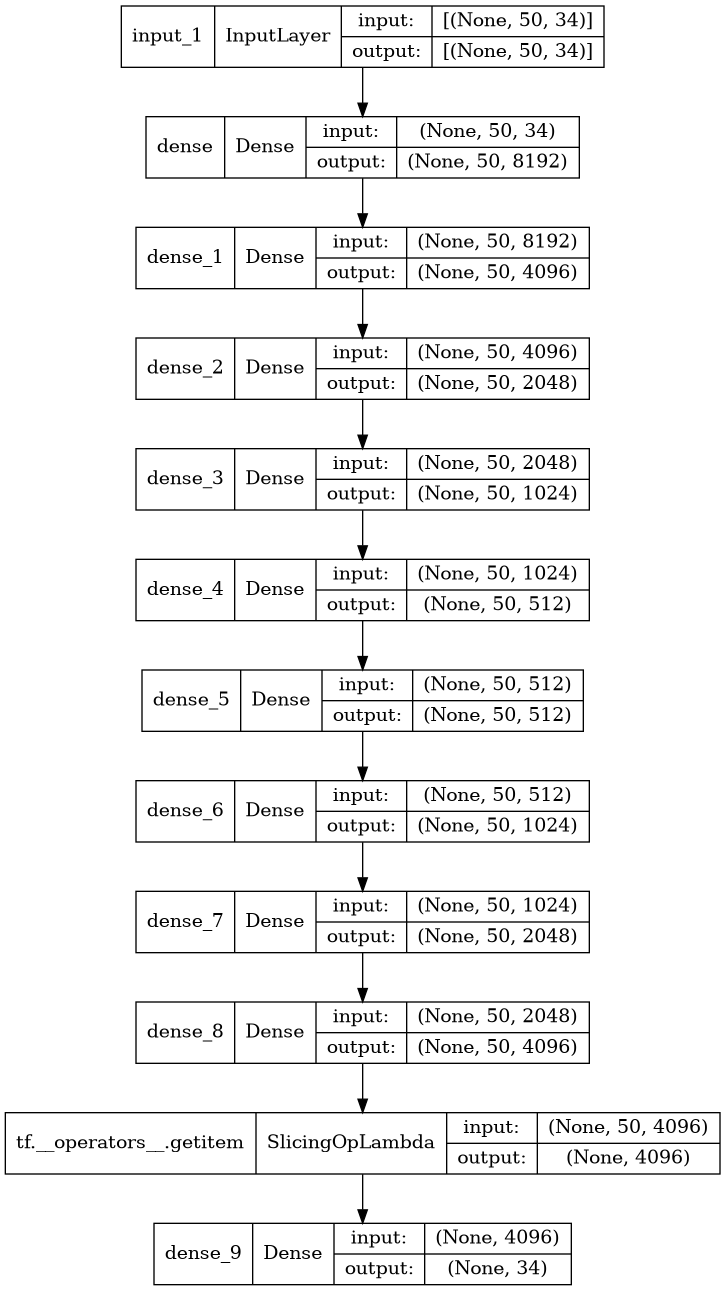

In [3]:
m11 = get_model_11(window_size=50, pt_cnt=17, latent_dim=512, num_layers=4)
tf.keras.utils.plot_model(m11, show_shapes=True, show_layer_names=True, expand_nested=True)

In [4]:
prediction_m11t1 = run_model_11(epochs=200, batch_size=64, optimizer=Adam(1e-4), 
                              window_size=50, dropout_rate=0.0, swap_rate=0.0, roll=False, model=m11)
print(prediction_m11t1.shape)
np.save('../autoencoder/results/toy_test/prediction_m11t1.npy', prediction_m11t1)

coords_corrected_windows.shape: (5000, 50, 34)
coords_augmented_windows.shape: (5000, 50, 34)
X min = 0.20, X max = 0.80
y min = 0.20, y max = 0.80
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 50, 34)]          0         
                                                                 
 dense (Dense)               (None, 50, 8192)          286720    
                                                                 
 dense_1 (Dense)             (None, 50, 4096)          33558528  
                                                                 
 dense_2 (Dense)             (None, 50, 2048)          8390656   
                                                                 
 dense_3 (Dense)             (None, 50, 1024)          2098176   
                                                                 
 dense_4 (Dense)             (None, 50, 512) 

In [5]:
prediction_m11t2 = run_model_11(epochs=200, batch_size=64, optimizer=Adam(1e-4), 
                              window_size=50, dropout_rate=0.01, swap_rate=0.01, roll=True, model=m11)
print(prediction_m11t2.shape)
np.save('../autoencoder/results/toy_test/prediction_m11t2.npy', prediction_m11t2)

coords_corrected_windows.shape: (5000, 50, 34)
coords_augmented_windows.shape: (85000, 50, 34)
X min = 0.20, X max = 0.80
y min = 0.20, y max = 0.80
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 50, 34)]          0         
                                                                 
 dense (Dense)               (None, 50, 8192)          286720    
                                                                 
 dense_1 (Dense)             (None, 50, 4096)          33558528  
                                                                 
 dense_2 (Dense)             (None, 50, 2048)          8390656   
                                                                 
 dense_3 (Dense)             (None, 50, 1024)          2098176   
                                                                 
 dense_4 (Dense)             (None, 50, 512)

In [4]:
m11 = get_model_11(window_size=50, pt_cnt=17, latent_dim=20, num_layers=2)
prediction_m11t3 = run_model_11(epochs=200, batch_size=64, optimizer=Adam(1e-4), 
                              window_size=50, dropout_rate=0.01, swap_rate=0.01, roll=False, model=m11)
print(prediction_m11t3.shape)
np.save('../autoencoder/results/toy_test/prediction_m11t3.npy', prediction_m11t3)

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 50, 34)]          0         
                                                                 
 dense (Dense)               (None, 50, 80)            2800      
                                                                 
 dense_1 (Dense)             (None, 50, 40)            3240      
                                                                 
 dense_2 (Dense)             (None, 50, 20)            820       
                                                                 
 dense_3 (Dense)             (None, 50, 20)            420       
                                                                 
 dense_4 (Dense)             (None, 50, 40)            840       
                                                                 
 tf.__operators__.getitem (S  (None, 40)               0     

In [5]:
m11 = get_model_11(window_size=50, pt_cnt=17, latent_dim=20, num_layers=1)
prediction_m11t4 = run_model_11(epochs=200, batch_size=64, optimizer=Adam(1e-4), 
                              window_size=50, dropout_rate=0.01, swap_rate=0.01, roll=False, model=m11)
print(prediction_m11t4.shape)
np.save('../autoencoder/results/toy_test/prediction_m11t4.npy', prediction_m11t4)

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 50, 34)]          0         
                                                                 
 dense_6 (Dense)             (None, 50, 40)            1400      
                                                                 
 dense_7 (Dense)             (None, 50, 20)            820       
                                                                 
 dense_8 (Dense)             (None, 50, 20)            420       
                                                                 
 tf.__operators__.getitem_1   (None, 20)               0         
 (SlicingOpLambda)                                               
                                                                 
 dense_9 (Dense)             (None, 34)                714       
                                                           

In [6]:
m11 = get_model_11(window_size=50, pt_cnt=17, latent_dim=10, num_layers=2)
prediction_m11t5 = run_model_11(epochs=200, batch_size=64, optimizer=Adam(1e-4), 
                              window_size=50, dropout_rate=0.01, swap_rate=0.01, roll=False, model=m11)
print(prediction_m11t5.shape)
np.save('../autoencoder/results/toy_test/prediction_m11t5.npy', prediction_m11t5)

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 50, 34)]          0         
                                                                 
 dense_10 (Dense)            (None, 50, 40)            1400      
                                                                 
 dense_11 (Dense)            (None, 50, 20)            820       
                                                                 
 dense_12 (Dense)            (None, 50, 10)            210       
                                                                 
 dense_13 (Dense)            (None, 50, 10)            110       
                                                                 
 dense_14 (Dense)            (None, 50, 20)            220       
                                                                 
 tf.__operators__.getitem_2   (None, 20)               0   

# Evaluate results

In [11]:
def animate_result_from_pts(
        pred_pts: Union[list, np.ndarray],  # List of tracked_points arrays
        gt_pts: Union[list, np.ndarray],  # List of tracked_points arrays
        x: int = 200,
        y: int = 200,
        fps: int = 50,
        bg_video: Union[sleap.Video, np.array] = None,
        bg_video_start_idx: int = 1,
        output_path: str = None
    ) -> animation.FuncAnimation:
    
    # if not isinstance(gt_pts, list):
    #     gt_pts = [gt_pts]
    frame_cnt = gt_pts.shape[0]
    n_plots = 1
    
    if bg_video is None:
        bg_video = np.ones((frame_cnt, y, x, 1))
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, n_plots, figsize=(8*n_plots, 8))
    if n_plots == 1:
        axes = [axes]  # Make axes iterable when only one subplot
    
    # Initialize plot elements for each subplot
    lines = []
    scats = []
    bg_imgs = []
    
    for ax in axes:
        ax.set_xlim(0, x)
        ax.set_ylim(0, y)
        ax.invert_yaxis()
        
        # Initialize empty line and scatter objects for each subplot
        line, = ax.plot([], [], 'b-', lw=1)
        gt_scat = ax.scatter([], [], c='green', s=30, label='input')
        pred_scat = ax.scatter([], [], c='blue', s=30, label='output')
        bg_img = ax.imshow(np.zeros((y, x)), cmap='gray', vmin=0, vmax=1)
        
        lines.append(line)
        scats.append([pred_scat, gt_scat])
        bg_imgs.append(bg_img)
        
        ax.legend()
    
    plt.tight_layout()

    def init():
        plot_elements = []
        for (pred_scat, gt_scat), bg_img in zip(scats, bg_imgs):
            pred_scat.set_offsets(np.zeros((0, 2)))
            gt_scat.set_offsets(np.zeros((0, 2)))
            plot_elements.extend([pred_scat, gt_scat, bg_img])
        return plot_elements

    def animate(frame):
        plot_elements = []
        
        # Update background (same for all subplots)
        if bg_video is not None:
            if isinstance(bg_video, np.ndarray):
                bg_frame = bg_video[frame + bg_video_start_idx]
            else:
                bg_frame = bg_video.get_frame(frame + bg_video_start_idx)
                
            for bg_img in bg_imgs:
                bg_img.set_array(bg_frame[:, :, 0])
        
        # Update each subplot
        for i, (gt_points, pred_points, (pred_scat, gt_scat)) in enumerate(zip([gt_pts], [pred_pts], scats)):
            # points = gt_points[frame]
            # points_closed = np.vstack([points, points[0]])
            
            # line.set_data(points_closed[:, 0], points_closed[:, 1])
            # print(pred_pts[frame].shape, gt_pts[frame].shape)
            pred_scat.set_offsets(pred_pts[frame])
            gt_scat.set_offsets(gt_pts[frame])
            
            plot_elements.extend([pred_scat, gt_scat, bg_imgs[i]])
            
        return plot_elements

    # Create animation
    anim = animation.FuncAnimation(fig, animate, init_func=init, 
                                 frames=frame_cnt, interval=50, blit=True)

    # Optional: save animation
    if output_path is not None:
        output_dir = os.path.dirname(output_path)
        os.makedirs(output_dir, exist_ok=True)
        anim.save(output_path, writer='ffmpeg', fps=fps)
        print(f"Animation saved to {output_path}")
        
    plt.tight_layout()
    return anim

In [9]:
toy_jelly_path = '/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/notebook/toy_jelly_v1.npy'
toy_jelly = np.load(toy_jelly_path)
prediction_m11t5.shape, toy_jelly.shape

((5000, 17, 2), (5000, 17, 2))

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/toy_jellyresult_v5.mp4
Animation saved to /home/mingxiao/Desktop/animation/toy_jellyresult_v5.mp4


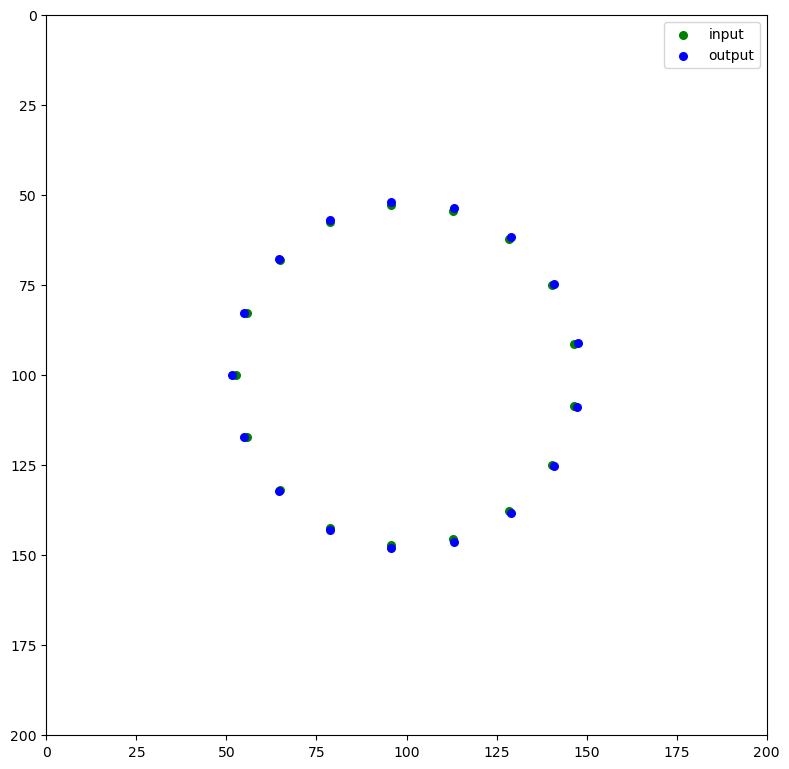

In [12]:
result_animation_path = '/home/mingxiao/Desktop/animation/toy_jellyresult_v5.mp4'
frames = 1000
animate_result_from_pts(pred_pts=prediction_m11t5[:frames], gt_pts=toy_jelly[:frames], bg_video_start_idx=0, output_path=result_animation_path)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/toy_jellyresult_v1.mp4
Animation saved to /home/mingxiao/Desktop/animation/toy_jellyresult_v1.mp4


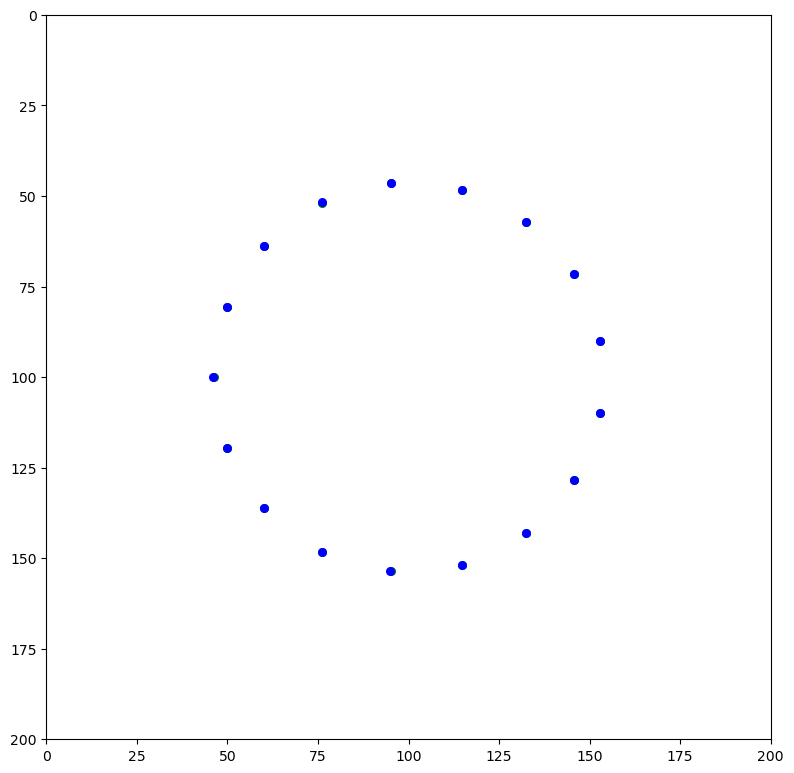

In [35]:
result_animation_path = '/home/mingxiao/Desktop/animation/toy_jellyresult_v1.mp4'
animate_result_from_pts(pred_pts=prediction_m11t1, gt_pts=toy_jelly, bg_video_start_idx=0, output_path=result_animation_path)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/toy_jellyresult_v2.mp4
Animation saved to /home/mingxiao/Desktop/animation/toy_jellyresult_v2.mp4


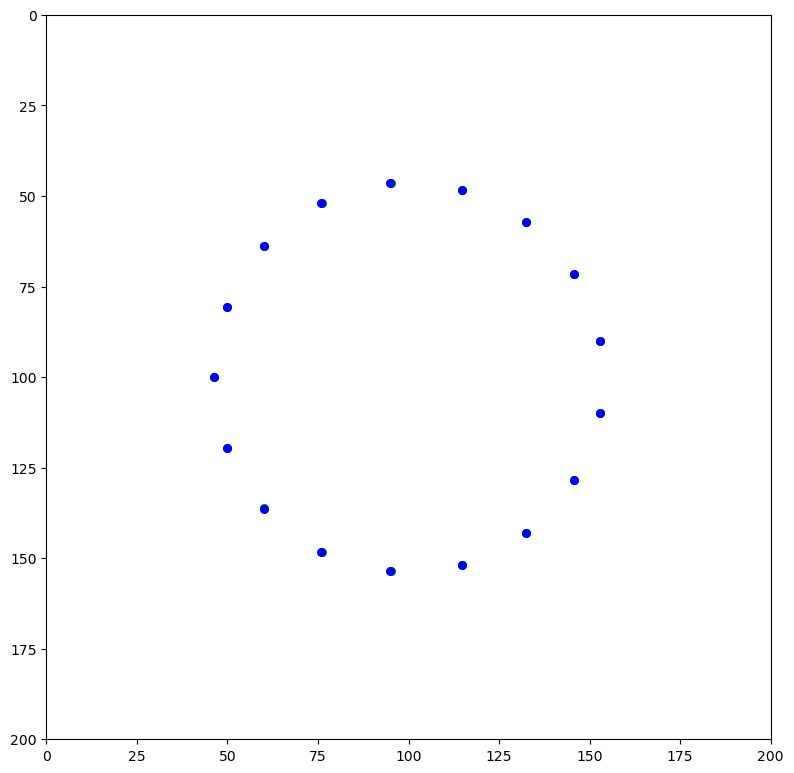

In [36]:
result_animation_path = '/home/mingxiao/Desktop/animation/toy_jellyresult_v2.mp4'
animate_result_from_pts(pred_pts=prediction_m11t2, gt_pts=toy_jelly, bg_video_start_idx=0, output_path=result_animation_path)